In [ ]:
#!unzip "/content/covid.zip" -d "/content/"

Archive:  /content/covid.zip
  inflating: /content/Covid19-dataset/test/Covid/0100.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0102.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0105.png  
  inflating: /content/Covid19-dataset/test/Covid/0106.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0108.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0111.jpg  
  inflating: /content/Covid19-dataset/test/Covid/0112.jpg  
  inflating: /content/Covid19-dataset/test/Covid/0113.jpg  
  inflating: /content/Covid19-dataset/test/Covid/0115.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0118.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0119.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/0120.jpg  
  inflating: /content/Covid19-dataset/test/Covid/094.png  
  inflating: /content/Covid19-dataset/test/Covid/096.png  
  inflating: /content/Covid19-dataset/test/Covid/098.jpeg  
  inflating: /content/Covid19-dataset/test/Covid/COVID-00003b.jpg 

In [ ]:
import os

In [ ]:
training_data_path = "/content/Covid19-dataset/train"
validation_data_path = "/content/Covid19-dataset/val"

In [ ]:
labels = ['Covid','Normal','Viral Pneumonia']

In [ ]:
os.listdir(training_data_path+'/Covid')

['COVID-00027.jpg',
 'COVID-00016.jpg',
 'COVID-00019.jpg',
 '049.jpeg',
 '073.jpg',
 '046.jpeg',
 '04.png',
 'COVID-00033.jpg',
 '081.jpeg',
 'COVID-00006.jpg',
 'COVID-00031.jpg',
 'COVID-00012.jpg',
 '069.jpg',
 '089.jpg',
 '031.jpeg',
 '055.jpeg',
 '056.jpg',
 'COVID-00013a.jpg',
 '052.jpeg',
 'COVID-00009.jpg',
 'COVID-00007.jpg',
 '088.jpeg',
 '042.jpeg',
 '091.jpg',
 'COVID-00010.jpg',
 'COVID-00023.jpg',
 'COVID-00030.jpg',
 '071.jpg',
 '01.jpeg',
 '012.jpeg',
 'COVID-00003b.jpg',
 'COVID-00018.jpg',
 'COVID-00038.jpg',
 '072.jpeg',
 '060.jpeg',
 '024.jpeg',
 'COVID-00029.jpg',
 '067.jpg',
 '06.jpeg',
 '043.jpeg',
 'COVID-00020.jpg',
 'COVID-00003a.jpg',
 '041.jpeg',
 'COVID-00008.jpg',
 '076.jpg',
 'COVID-00014.jpg',
 '090.jpeg',
 '078.jpeg',
 '040.jpeg',
 '080.jpg',
 '019.png',
 'COVID-00025.jpg',
 '051.jpeg',
 '084.jpeg',
 '064.jpg',
 'COVID-00011.jpg',
 '092.png',
 '054.jpeg',
 'COVID-00005.jpg',
 '032.jpeg',
 '048.jpeg',
 'COVID-00015a.png',
 '08.jpeg',
 'COVID-00001.jpg',

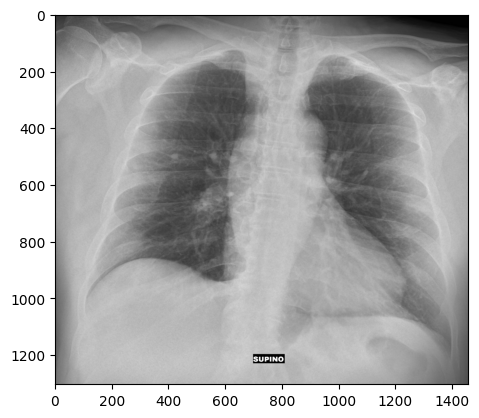

In [ ]:
# covid_image
import numpy as np
import matplotlib.pyplot as plt
covid_image = plt.imread(training_data_path+"/Covid/"+"010.png")

plt.imshow(covid_image)
plt.show()

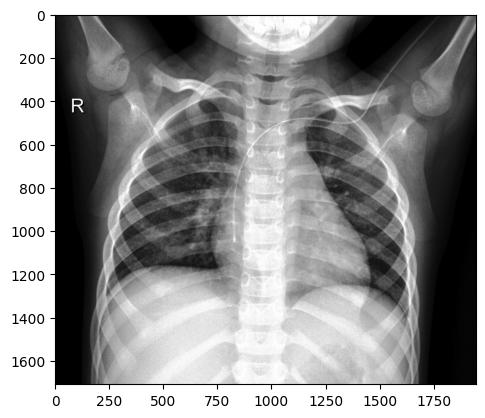

In [ ]:
# Normal Image
import numpy as np
import matplotlib.pyplot as plt
Normal_Image  = plt.imread(training_data_path+"/Normal/"+"01.jpeg")

plt.imshow(Normal_Image)
plt.show()

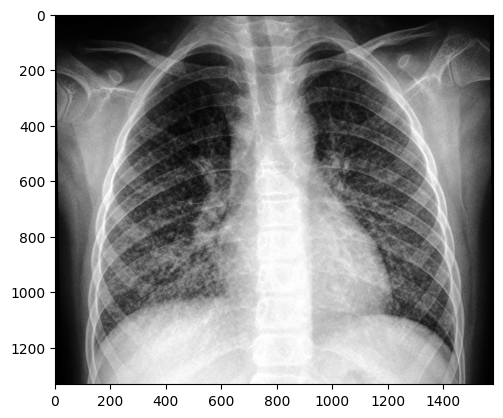

In [ ]:
# Pnemonia
Pnemonia_image = plt.imread(training_data_path+"/Viral Pneumonia"+"/01.jpeg")
plt.imshow(Pnemonia_image)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_data_preprocessing = ImageDataGenerator(1 / 255,
                                              rotation_range=0.2,
                                              shear_range=0.2,
                                              horizontal_flip=True)

val_data_preprocessing = ImageDataGenerator(1 / 255,
                                              rotation_range=0.2,
                                              shear_range=0.2,
                                              horizontal_flip=True)


In [ ]:
final_train_data = train_data_preprocessing.flow_from_directory(training_data_path,
                                             target_size=(224, 224),
                                             class_mode='categorical',
                                             classes = labels,
                                             batch_size = 20)


final_val_data = val_data_preprocessing.flow_from_directory(validation_data_path,
                                             target_size=(224, 224),
                                             class_mode='categorical',
                                             classes = labels)


Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [ ]:
# Architecture
import tensorflow
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Activation
from tensorflow.keras.activations import relu,sigmoid,softmax
from tensorflow.keras.applications import VGG19

vgg_obj = VGG19(input_shape = (224,224,3),weights = "imagenet",include_top = False)

for i in vgg_obj.layers:
  i.trainable = False

one_d_values = Flatten()(vgg_obj.output)

# give Flatten values to ANN
h1_out = Dense(units=128,kernel_initializer='he_uniform',activation='relu')(one_d_values)
h2_out = Dense(units=64,kernel_initializer='he_uniform',activation='relu')(h1_out)
h3_out = Dense(units=32,kernel_initializer='he_uniform',activation='relu')(h2_out)

output = Dense(units=3,kernel_initializer='glorot_uniform',activation='softmax')(h3_out)

model = Model(inputs = vgg_obj.input , outputs = output)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,25

 Total params: 23,246,211 (88.68 MB)

 Trainable params: 3,221,827 (12.29 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
model.compile(optimizer='adam',loss = 'categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(final_train_data , validation_data=final_val_data,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.6494 - loss: 13.1758 - val_accuracy: 0.8636 - val_loss: 1.4150
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 786ms/step - accuracy: 0.9203 - loss: 1.4246 - val_accuracy: 0.7879 - val_loss: 4.9576
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 764ms/step - accuracy: 0.9602 - loss: 0.6214 - val_accuracy: 0.8182 - val_loss: 5.6311
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 775ms/step - accuracy: 0.9761 - loss: 0.7887 - val_accuracy: 0.8636 - val_loss: 2.6513
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 833ms/step - accuracy: 0.9482 - loss: 0.9008 - val_accuracy: 0.9394 - val_loss: 1.3920


**Do Prediction**

In [ ]:
import cv2

In [ ]:
final_train_data.class_indices

{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}

In [ ]:
def pred_image(path_of_image):
  image = cv2.imread(path_of_image,1) # original image
  resized_image = cv2.resize(image , (224,224)) # resizing
  scaled_pixel_values = resized_image / 255  # scaled pixel values
  input_image = np.expand_dims(scaled_pixel_values , axis=0)

  result = model.predict(input_image)
  print(labels[np.argmax(result)])

  plt.imshow(image[:,:,::-1])
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Covid


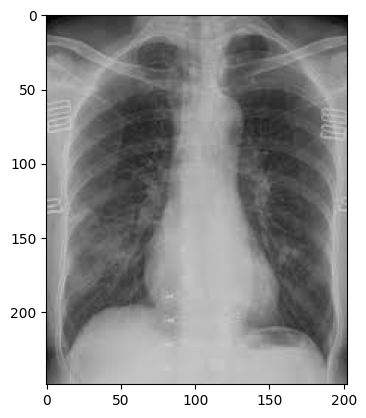

In [ ]:
pred_image("/content/covid.jpg")